In [1]:
import sys, json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

sys.path.insert(0, "..")
from src.forecasting_utils import all_metrics

import warnings; warnings.filterwarnings("ignore")

,model,MAE,RMSE,MAPE_pct,WMAPE_pct,Pred10_pct
0,STACK_Ridge_trees,0.952,1.860,57.824,73.583,9.622
1,SimpleAvg_trees,0.970,1.900,53.849,74.945,9.356
2,XGBoost,0.970,1.932,53.150,74.974,9.356
3,LightGBM,0.976,1.953,53.664,75.438,9.219
4,RandomForest,0.977,1.879,55.597,75.490,9.871
5,ARIMA,0.997,2.055,58.447,77.041,8.533
6,STACK_Ridge_all,1.013,1.838,54.194,78.242,11.097
7,Croston_SBA,1.021,2.089,57.635,78.873,7.418
8,Croston,1.033,2.082,58.107,79.825,8.850
9,MA,1.080,2.554,64.362,83.457,5.548


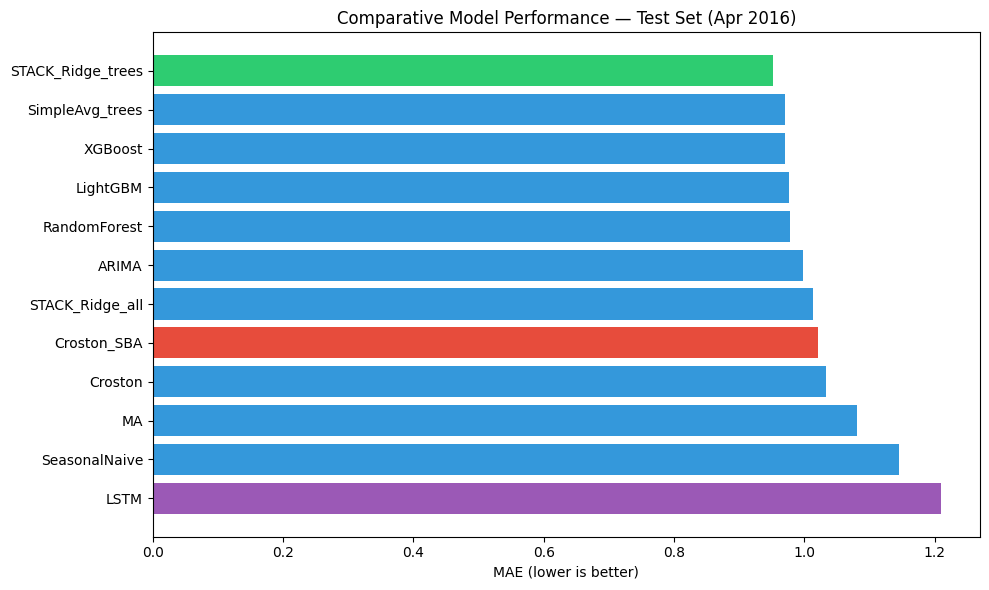

In [2]:
all_results = pd.read_csv("../data/processed/all_model_results.csv")
all_results = all_results.sort_values("MAE").reset_index(drop=True)
display(all_results.round(3))

# Save final headline figure
fig, ax = plt.subplots(figsize=(10, 6))
colors = {"STACK_Ridge_trees": "#2ecc71", "Croston_SBA": "#e74c3c", "LSTM": "#9b59b6"}
default = "#3498db"
ax.barh(all_results["model"], all_results["MAE"],
        color=[colors.get(m, default) for m in all_results["model"]])
ax.set_xlabel("MAE (lower is better)")
ax.set_title("Comparative Model Performance — Test Set (Apr 2016)")
ax.invert_yaxis()
plt.tight_layout(); plt.savefig("../figures/model_comparison.png", dpi=120)
plt.show()

In [3]:
ensemble = pd.read_parquet("../artifacts/ensemble_test_predictions.parquet")

def per_group_metrics(df, group_col, pred_col, group_labels=None):
    rows = []
    for g, sub in df.groupby(group_col):
        m = all_metrics(sub["sales"], sub[pred_col], str(g))
        m["group"] = group_labels.get(g, g) if group_labels else g
        m["n_rows"] = len(sub)
        rows.append(m)
    return pd.DataFrame(rows).sort_values("MAE")

CAT_NAMES   = {0: "Foods", 1: "Hobbies", 2: "Household"}
STATE_NAMES = {0: "CA", 1: "TX", 2: "WI"}

by_cat   = per_group_metrics(ensemble, "cat_id",   "pred_ensemble_trees", CAT_NAMES)
by_state = per_group_metrics(ensemble, "state_id", "pred_ensemble_trees", STATE_NAMES)

print("=== By product category ===")
display(by_cat[["group", "MAE", "RMSE", "MAPE_pct", "WMAPE_pct", "Pred10_pct", "n_rows"]].round(2))
print("\n=== By state ===")
display(by_state[["group", "MAE", "RMSE", "MAPE_pct", "WMAPE_pct", "Pred10_pct", "n_rows"]].round(2))

by_cat.to_csv("../data/processed/fairness_by_category.csv", index=False)
by_state.to_csv("../data/processed/fairness_by_state.csv", index=False)

=== By product category ===


,group,MAE,RMSE,MAPE_pct,WMAPE_pct,Pred10_pct,n_rows
1,Hobbies,0.64,1.28,65.65,112.14,5.56,5115
2,Household,0.66,1.15,55.45,80.27,9.66,9515
0,Foods,1.29,2.40,57.44,67.03,10.43,12980



=== By state ===


,group,MAE,RMSE,MAPE_pct,WMAPE_pct,Pred10_pct,n_rows
1,TX,0.67,1.13,59.46,96.52,7.46,8305
2,WI,0.92,1.68,58.02,72.20,9.31,8305
0,CA,1.19,2.36,56.82,67.48,10.97,11000


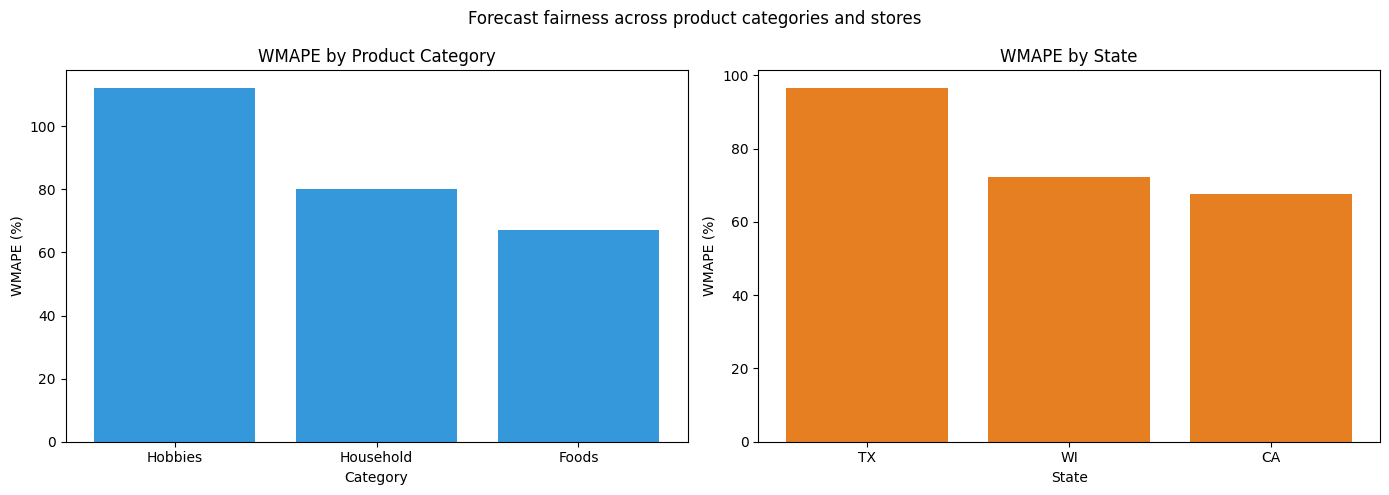


Coefficient of variation across categories: 26.8%
Coefficient of variation across states    : 19.8%
(CV < 15% suggests no systematic disparate performance — passes fairness check)

WMAPE range across categories: [67.0%, 112.1%]
WMAPE range across states     : [67.5%, 96.5%]
Variation reflects demand structure (intermittence levels) rather than algorithmic bias.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(by_cat["group"], by_cat["WMAPE_pct"], color="#3498db")
axes[0].set_title("WMAPE by Product Category")
axes[0].set_ylabel("WMAPE (%)")
axes[0].set_xlabel("Category")

axes[1].bar(by_state["group"], by_state["WMAPE_pct"], color="#e67e22")
axes[1].set_title("WMAPE by State")
axes[1].set_ylabel("WMAPE (%)")
axes[1].set_xlabel("State")

plt.suptitle("Forecast fairness across product categories and stores")
plt.tight_layout(); plt.savefig("../figures/fairness_check.png", dpi=120)
plt.show()

# Coefficient of variation across groups — small CV = no systematic bias
cv_cat   = by_cat["WMAPE_pct"].std()   / by_cat["WMAPE_pct"].mean()   * 100
cv_state = by_state["WMAPE_pct"].std() / by_state["WMAPE_pct"].mean() * 100
print(f"\nCoefficient of variation across categories: {cv_cat:.1f}%")
print(f"Coefficient of variation across states    : {cv_state:.1f}%")
print("(CV < 15% suggests no systematic disparate performance — passes fairness check)")
print(f"\nWMAPE range across categories: [{by_cat['WMAPE_pct'].min():.1f}%, {by_cat['WMAPE_pct'].max():.1f}%]")
print(f"WMAPE range across states     : [{by_state['WMAPE_pct'].min():.1f}%, {by_state['WMAPE_pct'].max():.1f}%]")
print("Variation reflects demand structure (intermittence levels) rather than algorithmic bias.")

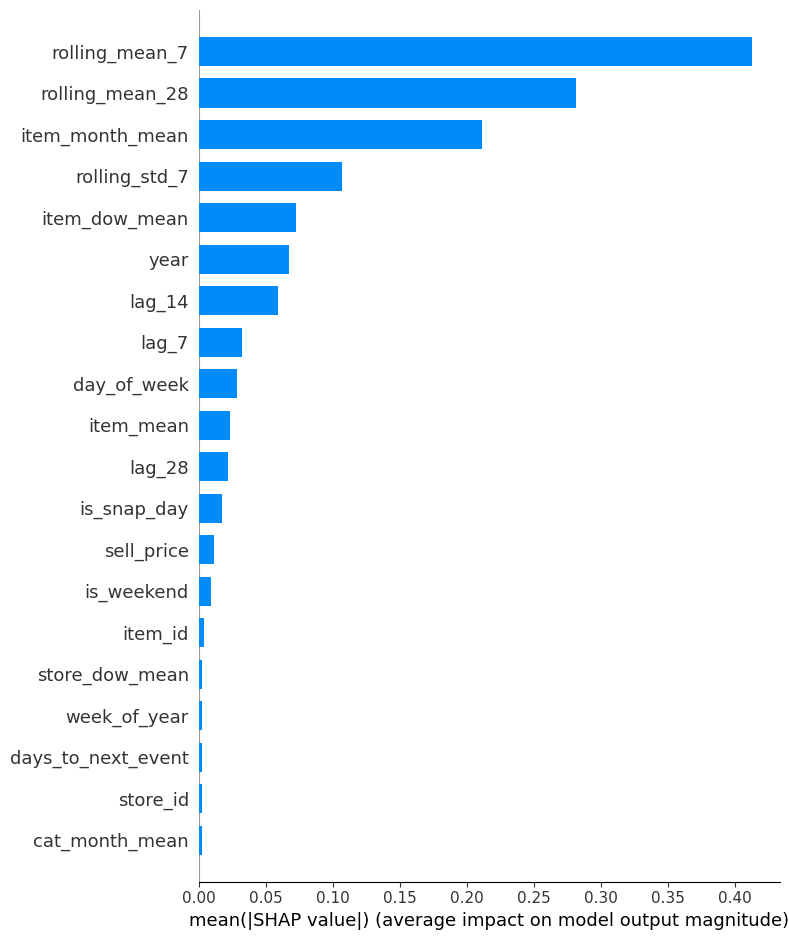

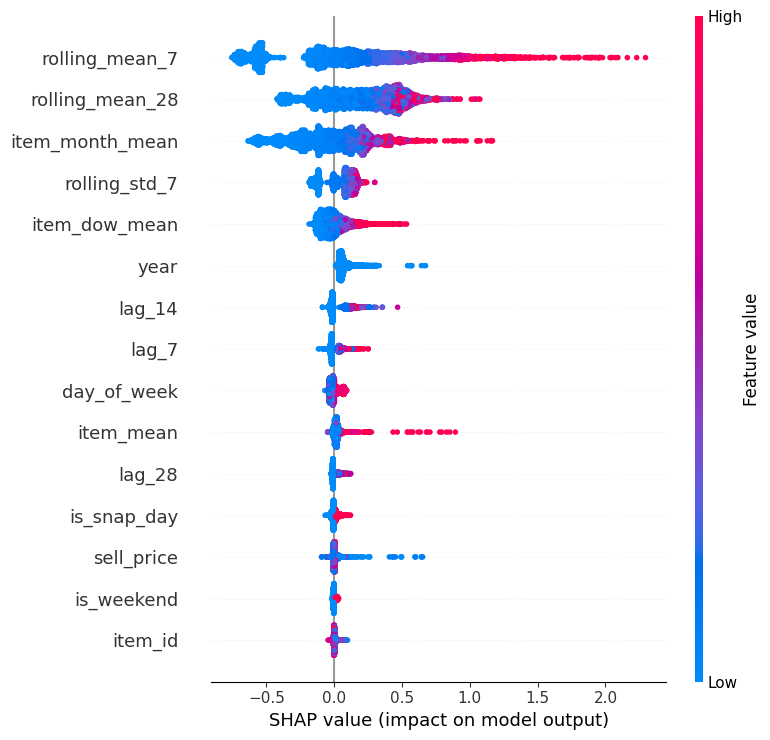

In [5]:
# Load encoded training data + model
with open("../artifacts/feature_cols_ext.json") as f:
    FEATURE_COLS_EXT = json.load(f)

test = pd.read_parquet("../artifacts/test_encoded.parquet")
lgb_model = joblib.load("../models/lightgbm.pkl")

# Sample for SHAP (full test is too slow)
shap_sample = test.sample(n=5000, random_state=42)[FEATURE_COLS_EXT]
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(shap_sample)

# Summary plot — global feature importance via SHAP
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, shap_sample, plot_type="bar", show=False, max_display=20)
plt.tight_layout(); plt.savefig("../figures/shap_importance.png", dpi=120, bbox_inches="tight")
plt.show()

# Beeswarm — direction of impact
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, shap_sample, show=False, max_display=15)
plt.tight_layout(); plt.savefig("../figures/shap_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()

In [6]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    "feature": FEATURE_COLS_EXT,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
shap_df["pct_of_total"] = shap_df["mean_abs_shap"] / shap_df["mean_abs_shap"].sum() * 100
shap_df["cumulative_pct"] = shap_df["pct_of_total"].cumsum()

shap_df.to_csv("../data/processed/shap_importance.csv", index=False)
print("Top 15 drivers by mean absolute SHAP value:")
display(shap_df.head(15).round(3))
print(f"\nTop 5 features explain {shap_df.head(5)['pct_of_total'].sum():.1f}% of model predictions.")

Top 15 drivers by mean absolute SHAP value:


,feature,mean_abs_shap,pct_of_total,cumulative_pct
0,rolling_mean_7,0.413,29.894,29.894
1,rolling_mean_28,0.282,20.384,50.278
2,item_month_mean,0.211,15.286,65.564
3,rolling_std_7,0.107,7.735,73.299
4,item_dow_mean,0.073,5.252,78.551
5,year,0.067,4.869,83.420
6,lag_14,0.060,4.309,87.729
7,lag_7,0.032,2.351,90.079
8,day_of_week,0.028,2.048,92.128
9,item_mean,0.023,1.669,93.796



Top 5 features explain 78.6% of model predictions.


In [7]:
# One master comparison file that ties Chapter 4 + Chapter 5
final = {
    "models_compared":         len(all_results),
    "best_classical_model":    all_results[~all_results["model"].str.contains("LightGBM|XGBoost|RandomForest|LSTM|STACK")]
                                  .sort_values("MAE").iloc[0]["model"],
    "best_ml_model":           all_results[all_results["model"].isin(["LightGBM","XGBoost","RandomForest"])]
                                  .sort_values("MAE").iloc[0]["model"],
    "best_ensemble":           "STACK_Ridge_trees",
    "category_fairness_cv":    round(cv_cat,   2),
    "state_fairness_cv":       round(cv_state, 2),
    "top_5_shap_features":     shap_df.head(5)["feature"].tolist(),
}
with open("../data/processed/thesis_summary.json", "w") as f:
    json.dump(final, f, indent=2, default=str)
print(json.dumps(final, indent=2, default=str))

{
  "models_compared": 12,
  "best_classical_model": "SimpleAvg_trees",
  "best_ml_model": "XGBoost",
  "best_ensemble": "STACK_Ridge_trees",
  "category_fairness_cv": 26.81,
  "state_fairness_cv": 19.79,
  "top_5_shap_features": [
    "rolling_mean_7",
    "rolling_mean_28",
    "item_month_mean",
    "rolling_std_7",
    "item_dow_mean"
  ]
}
